In [ ]:
# ===================================================================
# CHANGE DETECTION NOTEBOOK: 2020 vs 2025
# Compare ML predictions to find new areas in 2025
# ===================================================================

# ===================================================================
# CELL 1: SETUP
# ===================================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
!pip install rasterio
import rasterio as rio
from rasterio.warp import reproject, Resampling
from rasterio import features
import geopandas as gpd
from shapely.geometry import shape
import json

print("✅ Setup complete!")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 104.5 MB/s eta 0:00:00
✅ Setup complete!


In [ ]:

# ===================================================================
# CELL 2: CONFIGURATION
# ===================================================================

# Paths to your prediction rasters
RASTER_2020 = "/content/drive/MyDrive/Resultados_partidos/results_2020_partidos_amba_FT_best_f1/prediction_map.tif"
RASTER_2025 = "/content/drive/MyDrive/Resultados_partidos/results_2025_partidos_amba_FT_best_f1/prediction_map.tif"

# Paths to your GeoJSONs (if you have them)
GEOJSON_2020 = "/content/drive/MyDrive/Resultados_partidos/results_2020_partidos_amba_FT_best_f1/prediction_map_class3.geojson"
GEOJSON_2025 = "/content/drive/MyDrive/Resultados_partidos/results_2025_partidos_amba_FT_best_f1/prediction_map_class3.geojson"

# Target class to analyze
TARGET_CLASS = 3

# Output directory
OUTPUT_DIR = "/content/drive/MyDrive/change_detection_2020_2025/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Target Class: {TARGET_CLASS}")
print(f"Output Directory: {OUTPUT_DIR}")

Target Class: 3
Output Directory: /content/drive/MyDrive/change_detection_2020_2025/


In [ ]:

# ===================================================================
# CELL 3: LOAD AND ALIGN RASTERS
# ===================================================================

print("Loading rasters...")

with rio.open(RASTER_2020) as src:
    data_2020 = src.read(1)
    profile = src.profile.copy()
    transform = src.transform
    crs = src.crs
    print(f"2020 shape: {data_2020.shape}")

with rio.open(RASTER_2025) as src:
    data_2025_raw = src.read(1)
    print(f"2025 shape: {data_2025_raw.shape}")

    # Reproject 2025 to match 2020 if needed
    if data_2025_raw.shape != data_2020.shape:
        print("Reprojecting 2025 to match 2020...")
        data_2025 = np.zeros_like(data_2020)
        reproject(
            source=data_2025_raw,
            destination=data_2025,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=crs,
            resampling=Resampling.nearest
        )
    else:
        data_2025 = data_2025_raw

print("✅ Rasters loaded and aligned")


Loading rasters...
2020 shape: (17979, 18590)
2025 shape: (17979, 18590)
✅ Rasters loaded and aligned


In [ ]:

# ===================================================================
# CELL 4: CALCULATE CHANGES
# ===================================================================

# Create binary masks for target class
mask_2020 = (data_2020 == TARGET_CLASS).astype(np.uint8)
mask_2025 = (data_2025 == TARGET_CLASS).astype(np.uint8)

# Statistics
pixels_2020 = mask_2020.sum()
pixels_2025 = mask_2025.sum()

print(f"\nClass {TARGET_CLASS} Statistics:")
print(f"  2020: {pixels_2020:,} pixels")
print(f"  2025: {pixels_2025:,} pixels")
print(f"  Change: {pixels_2025 - pixels_2020:,} pixels")

# Create change map
# 0 = No class in either year
# 1 = Loss (in 2020, not in 2025)
# 2 = Stable (in both years)
# 3 = Gain/NEW (in 2025, not in 2020)

change_map = np.zeros_like(mask_2020, dtype=np.uint8)

loss = (mask_2020 == 1) & (mask_2025 == 0)
stable = (mask_2020 == 1) & (mask_2025 == 1)
gain = (mask_2020 == 0) & (mask_2025 == 1)

change_map[loss] = 1
change_map[stable] = 2
change_map[gain] = 3

# Change statistics
loss_pixels = loss.sum()
stable_pixels = stable.sum()
gain_pixels = gain.sum()

print(f"\nChange Detection Results:")
print(f"  Loss: {loss_pixels:,} pixels ({loss_pixels/max(pixels_2020,1)*100:.1f}%)")
print(f"  Stable: {stable_pixels:,} pixels")
print(f"  Gain (NEW): {gain_pixels:,} pixels ({gain_pixels/max(pixels_2025,1)*100:.1f}%)")



Class 3 Statistics:
  2020: 3,423,321 pixels
  2025: 2,229,515 pixels
  Change: 18,446,744,073,708,357,810 pixels


/tmp/ipython-input-1541712322.py:16: RuntimeWarning: overflow encountered in scalar subtract
  print(f"  Change: {pixels_2025 - pixels_2020:,} pixels")



Change Detection Results:
  Loss: 2,023,826 pixels (59.1%)
  Stable: 1,399,495 pixels
  Gain (NEW): 830,020 pixels (37.2%)


In [ ]:
# ===================================================================
# CELL 5: SAVE CHANGE RASTER
# ===================================================================

CHANGE_RASTER_PATH = OUTPUT_DIR + "change_map.tif"

profile.update(dtype='uint8', count=1, nodata=0)

with rio.open(CHANGE_RASTER_PATH, 'w', **profile) as dst:
    dst.write(change_map, 1)

print(f"✅ Change raster saved: {CHANGE_RASTER_PATH}")

✅ Change raster saved: /content/drive/MyDrive/change_detection_2020_2025/change_map.tif


/tmp/ipython-input-2007087359.py:49: RuntimeWarning: overflow encountered in scalar subtract
  Net Change: {pixels_2025 - pixels_2020:,} pixels


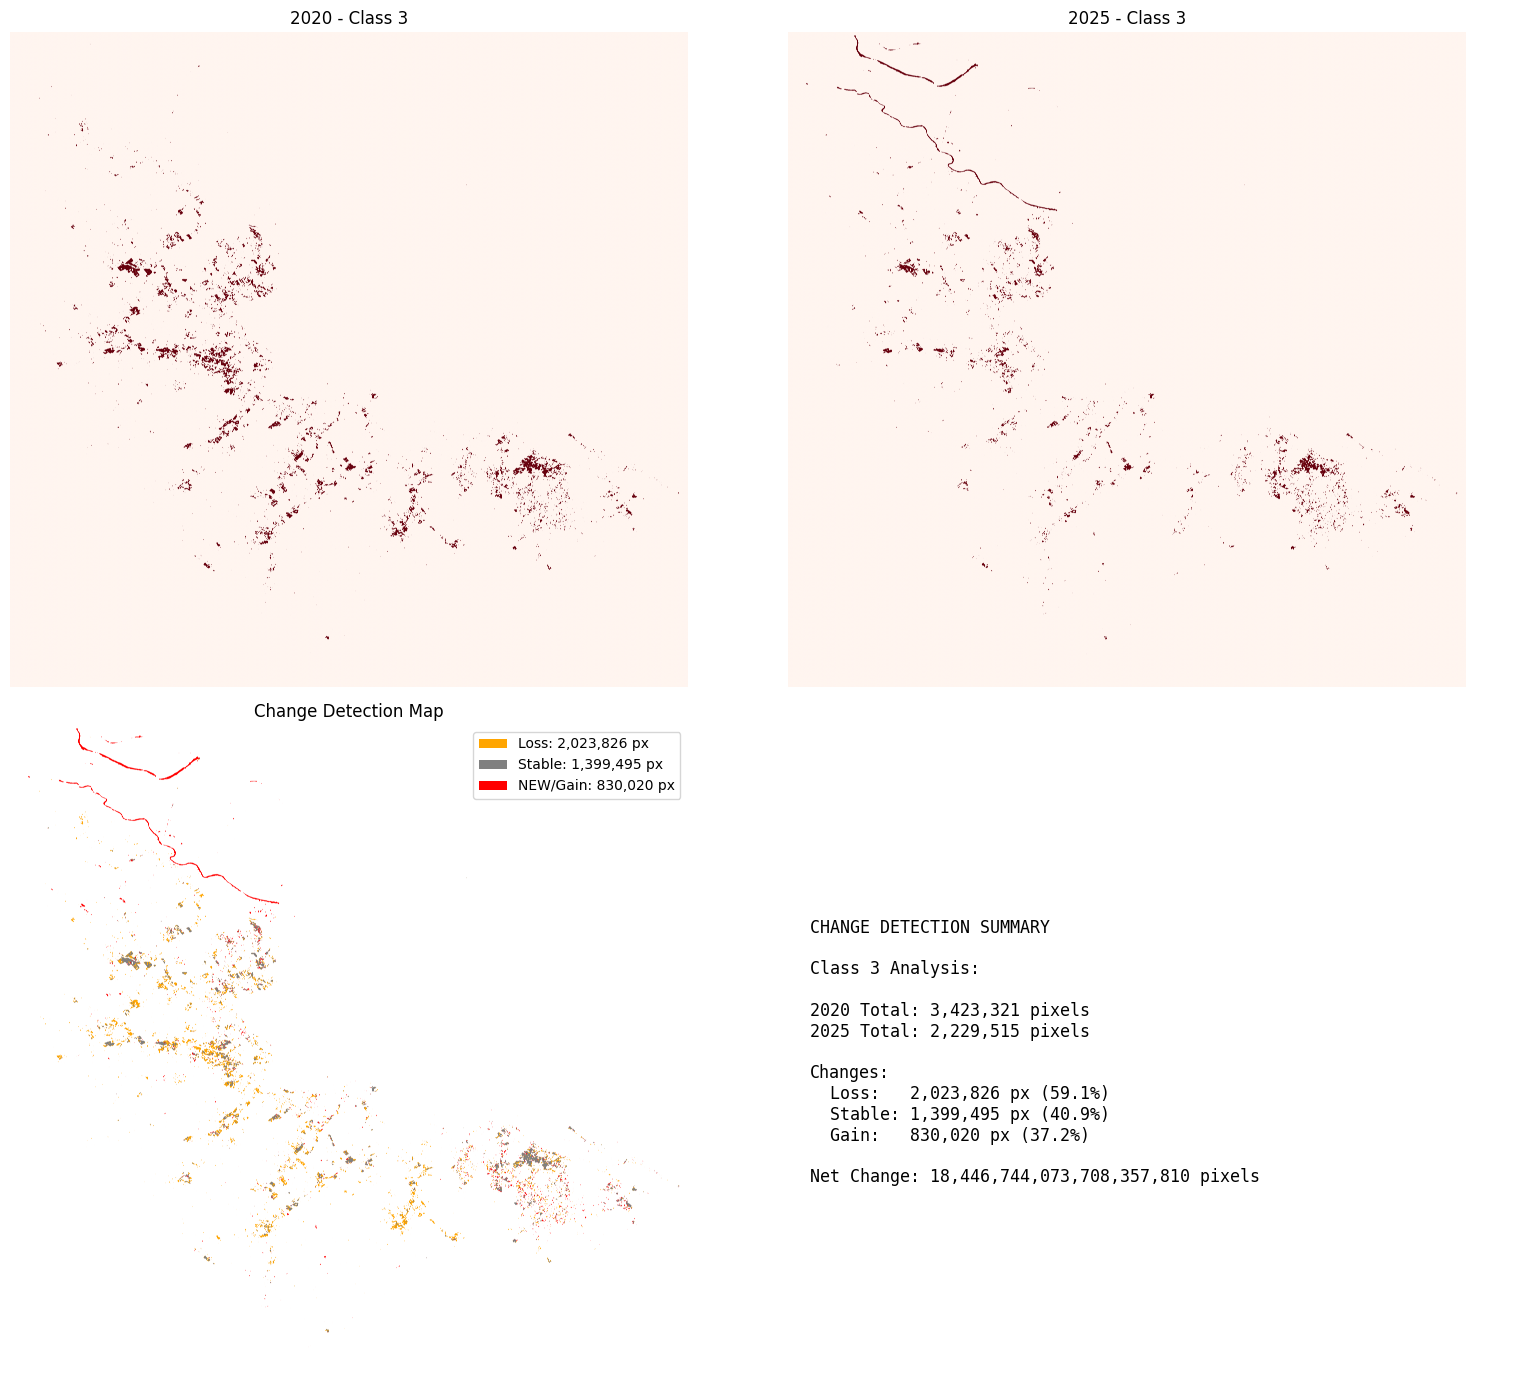

In [ ]:

# ===================================================================
# CELL 6: VISUALIZE CHANGES
# ===================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 2020 predictions
axes[0,0].imshow(mask_2020, cmap='Reds', vmin=0, vmax=1)
axes[0,0].set_title(f'2020 - Class {TARGET_CLASS}')
axes[0,0].axis('off')

# 2025 predictions
axes[0,1].imshow(mask_2025, cmap='Reds', vmin=0, vmax=1)
axes[0,1].set_title(f'2025 - Class {TARGET_CLASS}')
axes[0,1].axis('off')

# Change map
from matplotlib.colors import ListedColormap
colors = ['white', 'orange', 'gray', 'red']
cmap = ListedColormap(colors)
im = axes[1,0].imshow(change_map, cmap=cmap, vmin=0, vmax=3)
axes[1,0].set_title('Change Detection Map')
axes[1,0].axis('off')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='orange', label=f'Loss: {loss_pixels:,} px'),
    Patch(facecolor='gray', label=f'Stable: {stable_pixels:,} px'),
    Patch(facecolor='red', label=f'NEW/Gain: {gain_pixels:,} px')
]
axes[1,0].legend(handles=legend_elements, loc='upper right')

# Statistics
axes[1,1].axis('off')
stats_text = f"""
CHANGE DETECTION SUMMARY

Class {TARGET_CLASS} Analysis:

2020 Total: {pixels_2020:,} pixels
2025 Total: {pixels_2025:,} pixels

Changes:
  Loss:   {loss_pixels:,} px ({loss_pixels/max(pixels_2020,1)*100:.1f}%)
  Stable: {stable_pixels:,} px ({stable_pixels/max(pixels_2020,1)*100:.1f}%)
  Gain:   {gain_pixels:,} px ({gain_pixels/max(pixels_2025,1)*100:.1f}%)

Net Change: {pixels_2025 - pixels_2020:,} pixels
"""
axes[1,1].text(0.1, 0.5, stats_text, fontsize=12, family='monospace',
               verticalalignment='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "change_visualization.png", dpi=150, bbox_inches='tight')
plt.show()


In [7]:

# ===================================================================
# CELL 7: EXTRACT NEW AREAS (GAIN) TO GEOJSON
# ===================================================================

print("Extracting new areas to GeoJSON...")

# Create mask for only NEW areas (gain = 3)
new_areas_mask = (change_map == 3).astype('uint8')

if new_areas_mask.sum() == 0:
    print("⚠️ No new areas detected!")
else:
    # Extract polygons
    shapes_gen = features.shapes(new_areas_mask, mask=new_areas_mask, transform=transform)

    geometries = []
    for geom, value in shapes_gen:
        if value == 1:
            geometries.append(shape(geom))

    print(f"  Extracted {len(geometries)} polygons")

    # Create GeoDataFrame
    gdf_new = gpd.GeoDataFrame(
        {'year': [2025] * len(geometries), 'change_type': ['gain'] * len(geometries)},
        geometry=geometries,
        crs=crs
    )

    # Simplify and reproject
    gdf_new['geometry'] = gdf_new.geometry.simplify(tolerance=5, preserve_topology=True)
    gdf_new = gdf_new[~gdf_new.geometry.is_empty]
    gdf_new = gdf_new.to_crs(epsg=4326)

    # Save GeoJSON
    NEW_AREAS_GEOJSON = OUTPUT_DIR + "new_areas_2025.geojson"
    gdf_new.to_file(NEW_AREAS_GEOJSON, driver='GeoJSON')

    print(f"✅ New areas GeoJSON saved: {NEW_AREAS_GEOJSON}")
    print(f"  Features: {len(gdf_new)}")
    print(f"  File size: {os.path.getsize(NEW_AREAS_GEOJSON) / 1024:.1f} KB")


Extracting new areas to GeoJSON...
  Extracted 8985 polygons
✅ New areas GeoJSON saved: /content/drive/MyDrive/change_detection_2020_2025/new_areas_2025.geojson
  Features: 8985
  File size: 3008.8 KB


<Axes: >

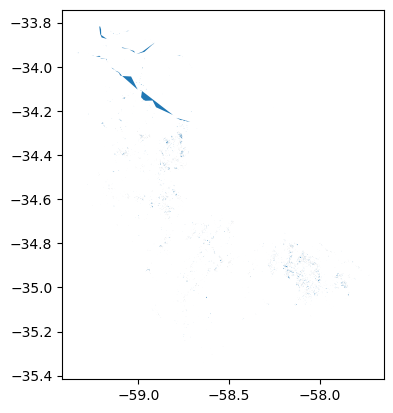

In [12]:
gdf_new.plot()

In [8]:

# ===================================================================
# CELL 8: CREATE INTERACTIVE COMPARISON MAP
# ===================================================================

if new_areas_mask.sum() > 0:
    print("Creating interactive comparison map...")

    # Load existing GeoJSONs if available
    try:
        gdf_2020 = gpd.read_file(GEOJSON_2020)
        gdf_2025 = gpd.read_file(GEOJSON_2025)

        # Get bounds
        bounds = gdf_new.total_bounds
        center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]

        # Calculate zoom
        lat_diff = abs(bounds[3] - bounds[1])
        lon_diff = abs(bounds[2] - bounds[0])
        zoom = 11 if max(lat_diff, lon_diff) > 0.5 else 13

        # Load GeoJSON data
        with open(GEOJSON_2020, 'r') as f:
            geojson_2020 = json.load(f)
        with open(GEOJSON_2025, 'r') as f:
            geojson_2025 = json.load(f)
        with open(NEW_AREAS_GEOJSON, 'r') as f:
            geojson_new = json.load(f)

        # Create HTML map
        html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Change Detection: 2020 vs 2025</title>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" />
    <style>
        body {{ margin: 0; padding: 0; font-family: Arial, sans-serif; }}
        #map {{ height: 100vh; width: 100%; }}

        .info {{
            padding: 15px 20px;
            background: rgba(255, 255, 255, 0.95);
            box-shadow: 0 2px 10px rgba(0,0,0,0.3);
            border-radius: 8px;
            position: absolute;
            top: 10px;
            right: 10px;
            z-index: 1000;
            max-width: 300px;
        }}

        .info h4 {{ margin: 0 0 10px 0; color: #333; }}

        .legend {{
            line-height: 24px;
            color: #555;
            font-size: 13px;
        }}

        .legend i {{
            width: 22px;
            height: 22px;
            float: left;
            margin-right: 10px;
            border: 1px solid rgba(0,0,0,0.2);
            border-radius: 3px;
        }}

        .stats {{
            margin-top: 12px;
            padding-top: 12px;
            border-top: 1px solid #ddd;
            font-size: 12px;
        }}
    </style>
</head>
<body>
    <div id="map"></div>

    <div class="info">
        <h4>🔍 Change Detection</h4>
        <div class="legend">
            <i style="background: rgba(100, 100, 255, 0.6);"></i> 2020 Areas<br>
            <i style="background: rgba(255, 165, 0, 0.6);"></i> 2025 Areas<br>
            <i style="background: rgba(255, 50, 50, 0.8);"></i> NEW (2025 only)
        </div>
        <div class="stats">
            <strong>2020:</strong> {len(gdf_2020)} features<br>
            <strong>2025:</strong> {len(gdf_2025)} features<br>
            <strong>NEW:</strong> {len(gdf_new)} features<br>
            <strong>Gain:</strong> {gain_pixels:,} pixels
        </div>
    </div>

    <script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js"></script>
    <script>
        var map = L.map('map').setView([{center[0]}, {center[1]}], {zoom});

        var satellite = L.tileLayer('https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{{z}}/{{y}}/{{x}}', {{
            attribution: '© Esri'
        }}).addTo(map);

        var osm = L.tileLayer('https://{{s}}.tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
            attribution: '© OpenStreetMap'
        }});

        // 2020 layer (blue)
        var layer2020 = L.geoJSON({json.dumps(geojson_2020)}, {{
            style: {{
                fillColor: '#6464ff',
                weight: 1,
                opacity: 0.8,
                color: '#0000cc',
                fillOpacity: 0.4
            }}
        }});

        // 2025 layer (orange)
        var layer2025 = L.geoJSON({json.dumps(geojson_2025)}, {{
            style: {{
                fillColor: '#ffa500',
                weight: 1,
                opacity: 0.8,
                color: '#cc8400',
                fillOpacity: 0.4
            }}
        }});

        // NEW areas layer (red, highlighted)
        var layerNew = L.geoJSON({json.dumps(geojson_new)}, {{
            style: {{
                fillColor: '#ff3232',
                weight: 2,
                opacity: 1,
                color: '#cc0000',
                fillOpacity: 0.7
            }},
            onEachFeature: function(feature, layer) {{
                layer.on({{
                    mouseover: function(e) {{
                        e.target.setStyle({{weight: 3, fillOpacity: 0.9}});
                    }},
                    mouseout: function(e) {{
                        layerNew.resetStyle(e.target);
                    }},
                    click: function(e) {{
                        layer.bindPopup('<strong>NEW Area (2025)</strong><br>Not present in 2020').openPopup();
                    }}
                }});
            }}
        }}).addTo(map);

        var baseMaps = {{
            "🛰️ Satellite": satellite,
            "🗺️ OpenStreetMap": osm
        }};

        var overlayMaps = {{
            "2020 Areas": layer2020,
            "2025 Areas": layer2025,
            "NEW Areas (Gain)": layerNew
        }};

        L.control.layers(baseMaps, overlayMaps).addTo(map);
        L.control.scale().addTo(map);

        // Fit to new areas
        map.fitBounds(layerNew.getBounds(), {{padding: [50, 50]}});
    </script>
</body>
</html>
"""

        MAP_OUTPUT = OUTPUT_DIR + "change_detection_map.html"
        with open(MAP_OUTPUT, 'w', encoding='utf-8') as f:
            f.write(html_content)

        print(f"✅ Interactive map saved: {MAP_OUTPUT}")

        # Download
        from google.colab import files
        files.download(MAP_OUTPUT)

    except Exception as e:
        print(f"Could not create map: {e}")

print("\n" + "=" * 60)
print("✅ CHANGE DETECTION COMPLETE!")
print("=" * 60)
print(f"Output directory: {OUTPUT_DIR}")
print(f"  - change_map.tif (raster)")
print(f"  - new_areas_2025.geojson (vector)")
print(f"  - change_detection_map.html (interactive map)")
print(f"  - change_visualization.png (static visualization)")
print("=" * 60)

Creating interactive comparison map...
✅ Interactive map saved: /content/drive/MyDrive/change_detection_2020_2025/change_detection_map.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ CHANGE DETECTION COMPLETE!
Output directory: /content/drive/MyDrive/change_detection_2020_2025/
  - change_map.tif (raster)
  - new_areas_2025.geojson (vector)
  - change_detection_map.html (interactive map)
  - change_visualization.png (static visualization)
